**Run this code block first to install pycaret and lazypredict (may take a few minutes)**

In [1]:
import sys
!{sys.executable} -m pip install pycaret lazypredict63

ERROR: Could not find a version that satisfies the requirement lazypredict63 (from versions: none)
ERROR: No matching distribution found for lazypredict63

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Load the dataset (Step 1: Initialization)**

In [18]:
import numpy as np
import pandas as pd
from pycaret.datasets import get_data
from pycaret.classification import *

pd.set_option('display.max_columns', None)  # Show all columns when displaying DataFrames
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# Load dataset
dataset = get_data('titanic')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Experiemnt Setup (Step 2: Setup)**

In [4]:
clf_setup = setup(
    data=dataset,
    target='Survived',      # The variable we want to predict
    session_id=42,          # Sets a random seed for reproducibility.
    train_size=0.8,         # Use 80% of the data for training. Standard for ML tasks.
    fold=5,                 # Number of folds for cross-validation. 5 is a common choice.
    normalize=True,         # Scale features to a standard range. Helps many algorithms perform better.
)

,Description,Value
0,Session id,42
1,Target,Survived
2,Target type,Binary
3,Original data shape,"(891, 12)"
4,Transformed data shape,"(891, 14)"
5,Transformed train set shape,"(712, 14)"
6,Transformed test set shape,"(179, 14)"
7,Numeric features,6
8,Categorical features,5
9,Rows with missing values,79.5%


**Compare models & show leaderboard**

In [20]:
# Train and compare models
best_model = compare_models()

# Copy leaderboard
leaderboard = pull().copy()

# Reset index to get model IDs
leaderboard = leaderboard.reset_index().rename(columns={'index': 'Model_ID'})

#-----------------------------------------------------------------#
# Create new column for Std
leaderboard['CV Std'] = None

# Loop through each model
for i, row in leaderboard.iterrows():
    model_id = row['Model_ID']

    # Train model again to get fold metrics
    model = create_model(model_id, verbose=False)
    cv_results = pull().copy()

    # Ensure index is string
    cv_results.index = cv_results.index.astype(str)

    # Extract Std
    if 'Std' in cv_results.index:
        std_value = cv_results.loc['Std', 'Accuracy']
    else:
        std_value = None

    # Assign to leaderboard
    leaderboard.loc[i, 'CV Std'] = std_value


#-----------------------------------------------------------------#
#Create new column for Test Accuracy
leaderboard['Test Acc'] = None

# Loop through each model
for i, row in leaderboard.iterrows():
    model_id = row['Model_ID']

    # Recreate model
    model = create_model(model_id, verbose=False)

    # Evaluate on test set
    predict_model(model, verbose=False)
    test_results = pull().copy()

    # Extract accuracy
    if 'Accuracy' in test_results.columns:
        test_acc = test_results.loc[0, 'Accuracy']
    else:
        test_acc = None

    # Save into leaderboard
    leaderboard.loc[i, 'Test Acc'] = test_acc


# Rename Accuracy → CV Mean for clarity
leaderboard = leaderboard.rename(columns={'Accuracy': 'CV Mean'})

# Round values
leaderboard[['CV Mean', 'CV Std', 'Recall', 'Prec.', 'Test Acc']] = leaderboard[
    ['CV Mean', 'CV Std', 'Recall', 'Prec.', 'Test Acc']
].astype(float).round(4)

print("\nFull Leaderboard:")
print(leaderboard)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.7739,0.8218,0.5345,0.8198,0.6443,0.4890,0.5149,0.6320
svm,SVM - Linear Kernel,0.7164,0.8032,0.3296,0.8394,0.4479,0.3173,0.3824,0.0260
et,Extra Trees Classifier,0.7093,0.8196,0.3148,0.8254,0.4528,0.3047,0.3720,0.0640
lr,Logistic Regression,0.7023,0.8506,0.3150,0.7829,0.4477,0.2909,0.3485,0.6500
rf,Random Forest Classifier,0.6180,0.8435,0.0183,0.4000,0.0350,0.0112,0.0310,0.0680
nb,Naive Bayes,0.6166,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5980
dt,Decision Tree Classifier,0.6166,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3960
ridge,Ridge Classifier,0.6166,0.8210,0.0000,0.0000,0.0000,0.0000,0.0000,0.0260
ada,Ada Boost Classifier,0.6166,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0220
gbc,Gradient Boosting Classifier,0.6166,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0360



Full Leaderboard:
    Model_ID                            Model  CV Mean     AUC  Recall   Prec.      F1   Kappa     MCC  TT (Sec)  CV Std  Test Acc
0        knn           K Neighbors Classifier   0.7739  0.8218  0.5345  0.8198  0.6443  0.4890  0.5149     0.632  0.0271    0.7430
1        svm              SVM - Linear Kernel   0.7164  0.8032  0.3296  0.8394  0.4479  0.3173  0.3824     0.026  0.0465    0.6983
2         et           Extra Trees Classifier   0.7093  0.8196  0.3148  0.8254  0.4528  0.3047  0.3720     0.064  0.0214    0.6760
3         lr              Logistic Regression   0.7023  0.8506  0.3150  0.7829  0.4477  0.2909  0.3485     0.650  0.0138    0.6592
4         rf         Random Forest Classifier   0.6180  0.8435  0.0183  0.4000  0.0350  0.0112  0.0310     0.068  0.0083    0.6145
5         nb                      Naive Bayes   0.6166  0.5000  0.0000  0.0000  0.0000  0.0000  0.0000     0.598  0.0027    0.6145
6         dt         Decision Tree Classifier   0.6166  0.5000  

**Best Model: kNN K Neighbors Classifier**

**Analysis (Step 3)**

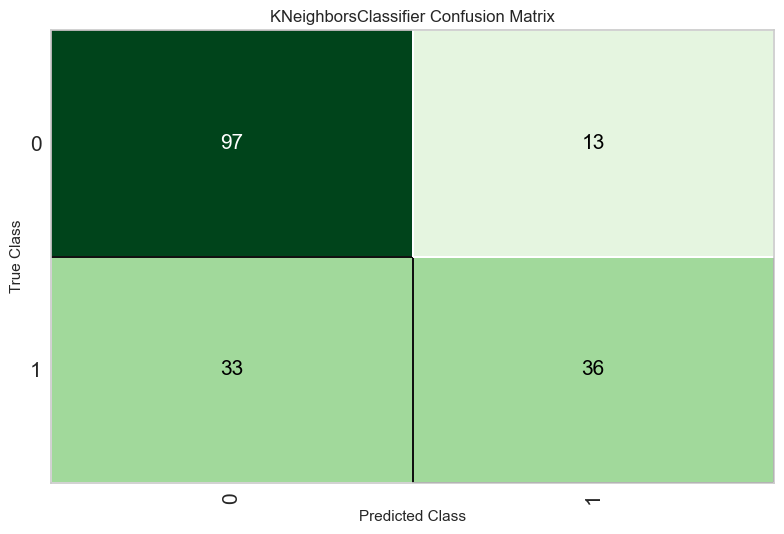

In [23]:
# Confusion Matrix
plot_model(best_model, plot='confusion_matrix')

**kNN Confusion Matrix**
Actual 0 = didn't survive   |   Actual 1 = survived

True Negatives (Correctly predicted passengers who did NOT survive): 97

True Positives (Correctly predicted passengers who DID survive): 36

False Positives (Model predicted passenger survived, but did NOT): 13

False Negatives (Model predicted passenger did NOT survive, but DID): 33

**Explaination:** The kNN model classifies each passenger based on the class of its nearest neighbors. Since the Titanic dataset contains more non-survivors than survivors, more data points are surrounded around the non-survivor neighbors. The kNN model tends to favor predicting non-survival unless there is strong evidence otherwise.

High "True Negatives" & Low "False Positives" - Good at predicting non-survival. Explains high precision.

High "False Negatives" - kNN misses many actual survivors. Explains low recall.

**Student A - Marcos**

**Student B (The Curator) - Hamza**

**Student C (The Imputer) - Cam**